# Simple Steps to Approaching a Machine Learning Project

As a newb, I find the breakdown of the approach quite helpful. It's pretty basic, but very helpful as a starting point.
1. Look at the big picture
2. Get the data
3. Explore and visualize the data to glean insights
4. Prepare the data for machine learning algoriths
5. Select a model and train it
6. Fine-tune your model
7. Present your solution
8. Launch, monitor, and maitain your system.

## The Project

In [1]:
import warnings
warnings.filterwarnings('ignore')

### 1. Look at the big picture

As a newb, I was so excited to jump into the machine learning part, all the technical fun, that I forgot that all of this work is to serve a purpose. We
are modeling for the data to do something important. So, as we do in software engineering, we must first define what we are trying to achieve, for what purpose, and further define the parameters of the project.

**The dataset**: In this practive project we will be working with California Housing Price dataset from the 1990s.

**Our goal**: Build a model that can reliably predict the housing prices in the area 

We need to further consider the nature of the challenge before us and answer few more important questions:
- What mode of training will we be using? [Supervised Learning]
- What kind of challenge task is it? [Regression]
- Do we need to use batch learning or online learning? [Batch]

(With my limited knowledge, i've tried to answer the questions by putting them in the square brackets.)

Nailed the first and the third :P

Learned a little more on the second: The task is indeed a regression task. But it is a multiple regression task (because we are going to use multiple features to make our prediction). It is also a univariate regression task (because we are only predicting a single value).

#### Select a performance measure

A performance measure is simply a function we use to quantify the error of the model.

Here we will be using *root mean square error* (RMSE) to check the performance of our model. While this is a typical measure we would use for a regression 
task we might prefer to use another measure for a different purpose.

For example: RMSE is very sensitive to outliers. If our dataset had more outliers we might consider using the *mean absolute error* (MAE) to check our models
performance. As part of our project i'm definitely going to try out both and see what happens.

**PS**: Though I understood RMSE and MAE and why we pick one over the other. I would be lying if I said I fully understood all aspects of picking a performance
measure. But I do have a sense of the intuition behind it - and for now that should be good enough.

#### Check your assumptions

As in life, so it is machine learning.

- Do you truly understand the nature of the problem?
- Do you know what you need to output?
- How are downstream systems/users going to use your output?
- Review. Never work alone or in the dark. Always ask for another set of eyes and a brain (preferrably one better that your own - **this here is just my humble opinion**)

### 2. Get the Data

Okay. The newb me expected this here to be step 1. I'm glad I was swiftly corrected.

But now we get to get the data. Wohooo!

#### Download the data

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

Finally some code!

If you are wondering how I got the above code. I would recommend checking the book out.

But what we are essentially doing is: downloadign the data set so that we can play with it.

In [3]:
housing = load_housing_data()

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info() # just getting a feel of the data. Look at the memory at the bottom not a big deal today, but who knows what the morrow brings.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Eeeks. Some of these columns are clearly badly named. That's a lot of total rooms and bedrooms. How big of a family do they have? :P

In [7]:
housing["ocean_proximity"].value_counts() # so much simpler that using a group by and count.

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

#### Selecting a test set

An important thing to do. Since we want a reliable test of our models performance after we train it. We want to take a part of our data out. Our model
will never learn on this data - it is our test set. This is our models true exam.

Poor thing.

Note: There are different ways to split this efficiently. But at this point the principle is the main thing.

In [8]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [9]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)

print(f"Training Set Length: {len(train_set)}, Test Set Length: {len(test_set)}")

Training Set Length: 16512, Test Set Length: 4128


The book explain this part better - but to have an more "even" training and test dataset so it is representative of the different categories we 
bin the data on income (we can probably do it on other variables as well) and then use an existing splitter to do the split for us.

In [10]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set = strat_splits[0]

### 3. Explore and visualize the data to glean insights

Now that we have the data. We need to get to know it a little bit more. Nothing too serious. We will take it slow at the beginning.

In [12]:
housing = strat_train_set.copy()
housing = housing.drop("ocean_proximity", axis=1)

#### Visualize

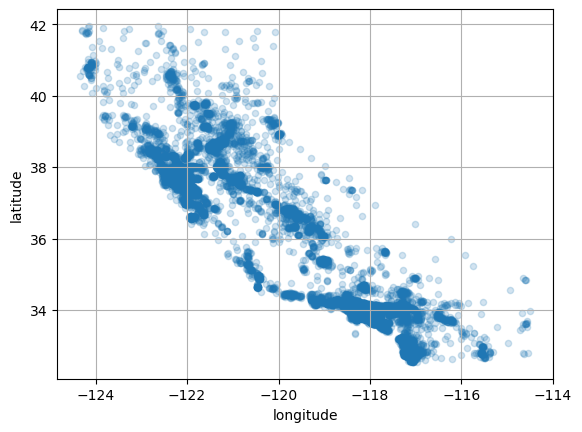

In [13]:
import matplotlib.pyplot as plt

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2) # the alpha 
plt.show()

Kinda cool. Looks like a map of California or a chunky arm. Probably just California since we are plotting latitudes and longitudes. Jokes aside, this does
give us a view of the distribution of the homes.

Let's look at the price distribution too.

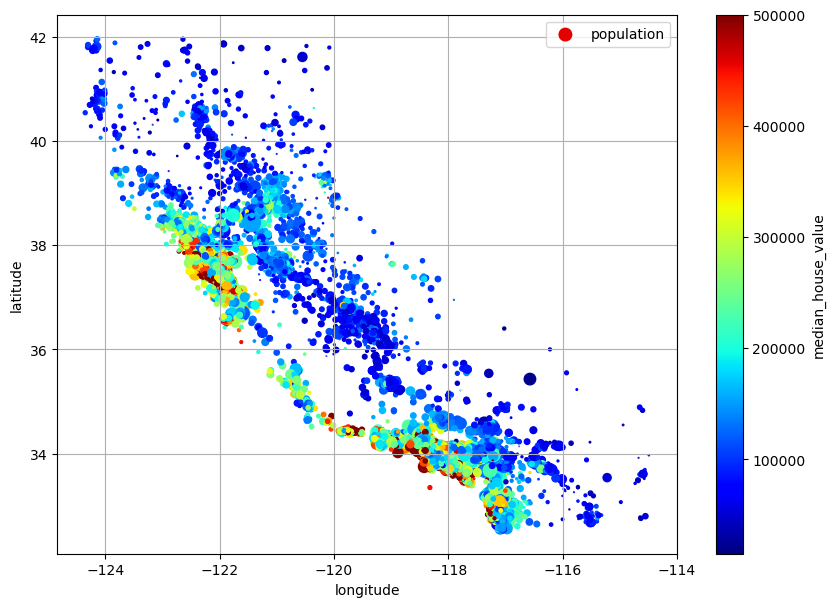

In [14]:
# not going to explain all the arguments. Looking up the documentation should suffice.
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

That's pretty sick. The houses close to the water are more expensive - who would have thunk?

Visualizng it gives us a much better picture of wath we are dealing with here in terms of the price and the distribution.

**Now let's check to see if there are any correlations between the many features**.

#### Look for correlations

In [15]:
corr_matrix = housing.corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859,-0.011167
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584,-0.084299
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175,-0.153218
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455,0.221154
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635,0.017573
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153,0.028069
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426,0.039278
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380,0.904441
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000,0.642887
income_cat,-0.011167,-0.084299,-0.153218,0.221154,0.017573,0.028069,0.039278,0.904441,0.642887,1.000000


I had a hard time reading the correlations above. So added some colour to the correlations. This gives us a much clearer picture of the correlations
between features.

In [16]:
df_styled = corr_matrix.style.background_gradient(cmap='Reds', vmin=0, vmax=10)
df_styled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859,-0.011167
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584,-0.084299
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175,-0.153218
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455,0.221154
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635,0.017573
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153,0.028069
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426,0.039278
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380,0.904441
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000,0.642887
income_cat,-0.011167,-0.084299,-0.153218,0.221154,0.017573,0.028069,0.039278,0.904441,0.642887,1.000000


Here's another way to look at correlations between features using visualizations.

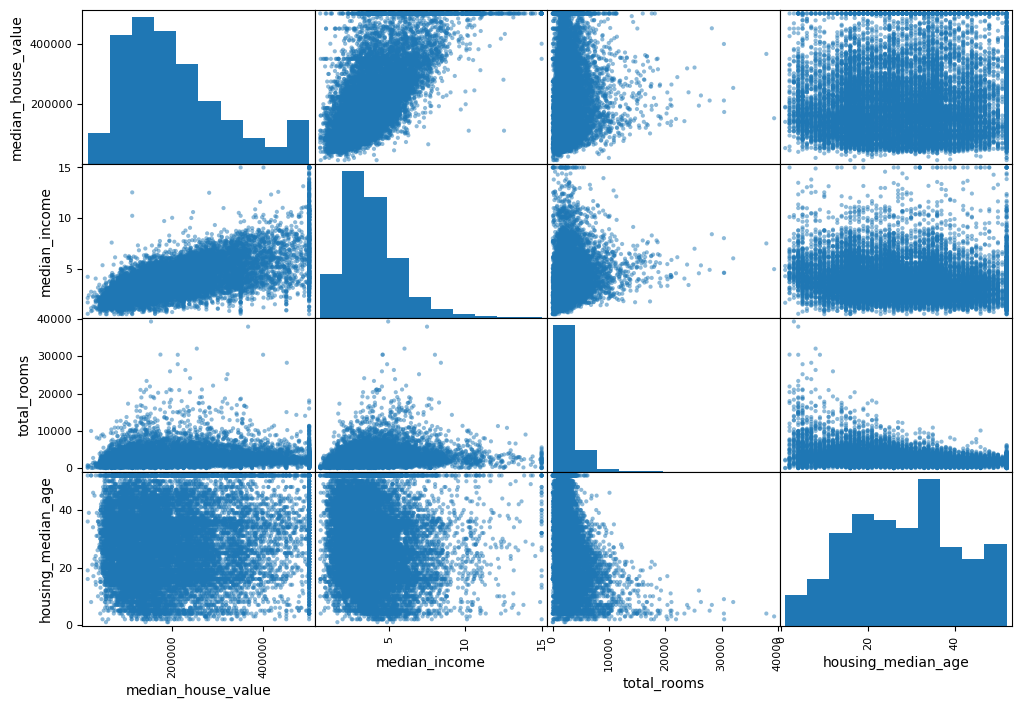

In [17]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

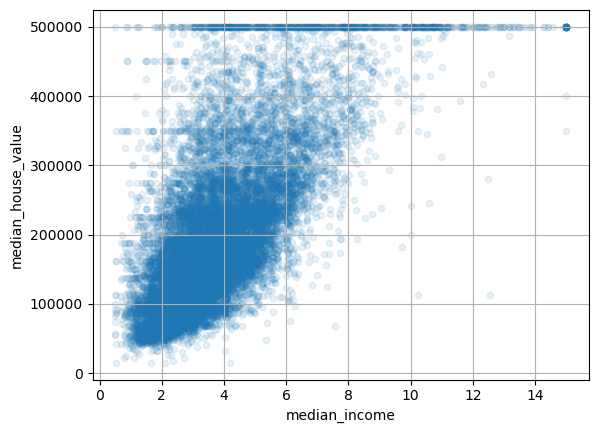

In [18]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

#### Experiment with Attribute Combinations
Some attributes when combined can reveal different relationships with the labels or the features so always understand the data and expeiriment with them.

In [19]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

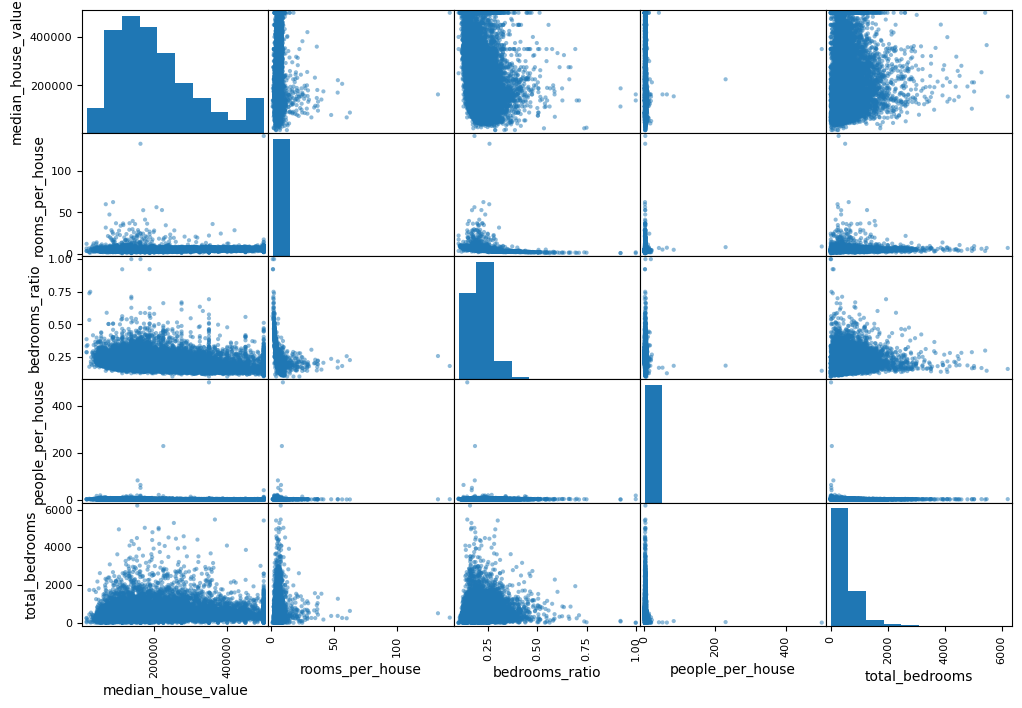

In [20]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "rooms_per_house", "bedrooms_ratio", "people_per_house", "total_bedrooms"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

### 4. Prepare the Data for Machine Learning Algorithms

The data that exists out there in the world won't automatically be fit for your machine learning model. Additionally, depending on the approach to your model
you migth want to prepare the data in different ways so that the model can work with it.

In [21]:
# We are going back to our clean split training set so that we don't have to deal with all the changes we made in the visualization section.
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

#### Clean the data

##### Missing Features
Machine learning models don't do well with missing values for features. We to clean up these missing values so that the model can better handle the dataset.

In [22]:
housing[housing["total_bedrooms"].isnull()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND,3
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN,3
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN,3
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN,4
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN,5
...,...,...,...,...,...,...,...,...,...,...
2348,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN,3
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,NEAR OCEAN,3
18241,-121.44,38.54,39.0,2855.0,NaN,1217.0,562.0,3.2404,INLAND,3
18493,-116.21,33.75,22.0,894.0,NaN,830.0,202.0,3.0673,INLAND,3


We have 168 rows that have empty values for total_bedrooms. What do we do about these? Well we have three options.
1) Get rid of the corresponding rows.
2) Get rid of the entire attribute/feature
3) Fill the empty value with a suitable default (such as a 0 or a mean)

We will go with the third option as it is the least destructive. Data is precious and so we want to be very careful when we remove datapoints.

Though there are many ways to handle this, we will be using a `SimpleImputer` to do it.

In [23]:
from sklearn.impute import SimpleImputer

help(SimpleImputer) # Just to get an idea of what the imputer does.

Help on class SimpleImputer in module sklearn.impute._base:

class SimpleImputer(_BaseImputer)
 |  SimpleImputer(*, missing_values=nan, strategy='mean', fill_value=None, copy=True, add_indicator=False, keep_empty_features=False)
 |
 |  Univariate imputer for completing missing values with simple strategies.
 |
 |  Replace missing values using a descriptive statistic (e.g. mean, median, or
 |  most frequent) along each column, or using a constant value.
 |
 |  Read more in the :ref:`User Guide <impute>`.
 |
 |  .. versionadded:: 0.20
 |     `SimpleImputer` replaces the previous `sklearn.preprocessing.Imputer`
 |     estimator which is now removed.
 |
 |  Parameters
 |  ----------
 |  missing_values : int, float, str, np.nan, None or pandas.NA, default=np.nan
 |      The placeholder for the missing values. All occurrences of
 |      `missing_values` will be imputed. For pandas' dataframes with
 |      nullable integer dtypes with missing values, `missing_values`
 |      can be set to eit

In [24]:
imputer = SimpleImputer(strategy="mean")

Though we were looking at the total_bedrooms attribute. It is advisable to handle all empty values in our dataset. The `SimpleImputer` can help us with
that as we can see below.

We can feed it all the numerical attributes from our dataset and let it figure out the appropirate value to fill in based on our selected stratergy.

In [25]:
housing_numerical = housing.select_dtypes(include=[np.number])

In [26]:
imputer.fit(housing_numerical)

SimpleImputer()

We can see the values it has computed for each attribute now.

In [27]:
dict(zip(housing_numerical.columns, imputer.statistics_))

{'longitude': -119.57312499999999,
 'latitude': 35.637746487403106,
 'housing_median_age': 28.577156007751938,
 'total_rooms': 2639.4027979651164,
 'total_bedrooms': 538.9490944689182,
 'population': 1425.5139292635658,
 'households': 499.99018895348837,
 'median_income': 3.8704281431686045}

Lets apply these to our dataset.

In [28]:
aoa = imputer.transform(housing_numerical) # this returns an array of array

In [29]:
aoa

array([[-1.2242e+02,  3.7800e+01,  5.2000e+01, ...,  1.5760e+03,
         1.0340e+03,  2.0987e+00],
       [-1.1838e+02,  3.4140e+01,  4.0000e+01, ...,  6.6600e+02,
         3.5700e+02,  6.0876e+00],
       [-1.2198e+02,  3.8360e+01,  3.3000e+01, ...,  5.6200e+02,
         2.0300e+02,  2.4330e+00],
       ...,
       [-1.1706e+02,  3.2590e+01,  1.3000e+01, ...,  2.8140e+03,
         7.6000e+02,  4.0616e+00],
       [-1.1840e+02,  3.4060e+01,  3.7000e+01, ...,  1.7250e+03,
         8.3800e+02,  4.1455e+00],
       [-1.2241e+02,  3.7660e+01,  4.4000e+01, ...,  6.8200e+02,
         2.1200e+02,  3.2833e+00]])

In [30]:
housing_tr = pd.DataFrame(aoa, columns=housing_numerical.columns,index=housing_numerical.index)

In [31]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292
...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455


##### How to handle text and categorical attributes
Most machine learning models can't deal with text well. This can be a problem when we have categorical values like seen below. Computers like numbers a lot more than they like anything else.

Generally such categorical values will be contrained to a set as we can see below. Hence we can easily convert these to numbers that represent each category. We shouldn't do this ourselves, but use sklearn to do it for us.

In [32]:
housing_cat = housing[["ocean_proximity"]]
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

In [33]:
from sklearn.preprocessing import OrdinalEncoder

help(OrdinalEncoder)

Help on class OrdinalEncoder in module sklearn.preprocessing._encoders:

class OrdinalEncoder(sklearn.base.OneToOneFeatureMixin, _BaseEncoder)
 |  OrdinalEncoder(*, categories='auto', dtype=<class 'numpy.float64'>, handle_unknown='error', unknown_value=None, encoded_missing_value=nan, min_frequency=None, max_categories=None)
 |
 |  Encode categorical features as an integer array.
 |
 |  The input to this transformer should be an array-like of integers or
 |  strings, denoting the values taken on by categorical (discrete) features.
 |  The features are converted to ordinal integers. This results in
 |  a single column of integers (0 to n_categories - 1) per feature.
 |
 |  Read more in the :ref:`User Guide <preprocessing_categorical_features>`.
 |
 |  .. versionadded:: 0.20
 |
 |  Parameters
 |  ----------
 |  categories : 'auto' or a list of array-like, default='auto'
 |      Categories (unique values) per feature:
 |
 |      - 'auto' : Determine categories automatically from the train

In [34]:
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [35]:
housing_cat_encoded

array([[3.],
       [0.],
       [1.],
       ...,
       [4.],
       [0.],
       [4.]])

In [36]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

**There is a problem with the above though:** Since we are using numerical values, the ML model will assume that those values close to each other are similar
i.e. 0 and 1 are more similar than 0 and 3. This is not always the case with categorical values.

Therefore, it is better to come up with a different represetnation for these categorical attributes using `OneHotEncoding` - i'm not going to go into 
explaining what this is, the book does a pretty good job of doing it.

In [37]:
from sklearn.preprocessing import OneHotEncoder

In [38]:
one_hot_encoder = OneHotEncoder()
housing_cat_1hot = one_hot_encoder.fit_transform(housing_cat)

In [39]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [40]:
one_hot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

##### Feature Scaling and Transformation

A dataset can have a whole bunch of features that have a whole lot of different units. Their
values can be all over the place relative to each other.

For example if you compare the longitutde to the total_bedrooms. You will see that the 
total_bedrooms are so much larger than the longitude values. Due to this our model might 
focus on the larger value. We avoid this by scaling our features.

There are two main ways we learn about at this point
- min-max scaling (normalization): This reduces the values so that it falls between a 0-1.
It is done basically likes so (x - min)/ (max - 1), where x is your value
- starndardization: here we do (x - mean) / std [std is the standard deviation]

In [41]:
# Example of a Standard Transformer
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
std_scaler.fit_transform(housing_numerical)

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]])

##### Custom Transformers

Though Sklearn has a lot of pre-existing transformers we can write our own custom transformers as well. Below we will write a simple
- Functional Transformer: Simple transformer that applies a function to the values i.e. rbf or log etc
- Custom transformer that are a little more elaborate

In [42]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_transformer.transform(housing["population"])

13096    7.362645
14973    6.501290
3785     6.331502
14689    7.520235
20507    7.555905
           ...   
14207    6.843750
13105    7.257708
19301    7.942362
19121    7.452982
19888    6.525030
Name: population, Length: 16512, dtype: float64

Now lets write a more complex transformer that leverages Cluster Similarity using KMeans. Here we are focussing more on the custom transformer that
we are writing rather than the purpose of the transformer or its functionality.

In [43]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans # https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html
from sklearn.metrics.pairwise import rbf_kernel

""" 
    We inherit from these two classes because they give us a few things that we then don't have to implement.
    BaseEstimator - gives us the get_params and set_params that allows us to easily tune our hyper parameters.
    TransformerMixin - gives us the fit_transform method for free (it simply calls fit and then transform)
"""
class ClusterSimilarity(BaseEstimator, TransformerMixin):

    # The args here are because we are using KMeans. n_clusters=10 means we find 10 clusters.
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    # we need to implement our fit and transform and fit should return self.
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    # This method is helpful when you want your output to be a dataframe
    def get_feature_names_out(self, names=None):
        return [f"Clusters {i} similarity" for i in range(self.n_clusters)]

In [44]:
cluster_similarity = ClusterSimilarity(n_clusters=8, random_state=42)
similarities = cluster_similarity.fit_transform(housing[["latitude", "longitude"]], sample_weight=housing_labels)
similarities

array([[2.99989020e-23, 9.87101580e-01, 3.75506719e-08, ...,
        4.75272706e-03, 5.55276904e-15, 5.96718583e-01],
       [4.66583712e-02, 1.37447800e-13, 1.28245628e-01, ...,
        2.28183664e-24, 9.23951428e-01, 1.79719494e-10],
       [9.48045501e-24, 6.97655446e-01, 7.45678494e-09, ...,
        2.80121257e-02, 2.01006641e-15, 3.01749088e-01],
       ...,
       [8.42605364e-01, 5.90323323e-25, 1.14841997e-05, ...,
        3.51133628e-39, 4.39061368e-02, 1.46260857e-20],
       [5.26989152e-02, 8.79494595e-14, 1.23233782e-01, ...,
        1.04149242e-24, 9.31723102e-01, 1.24807526e-10],
       [1.25445394e-22, 9.48789092e-01, 9.31495748e-08, ...,
        2.43833084e-03, 1.72523894e-14, 6.85973857e-01]])

In [45]:
similarities[:3].round(2)

array([[0.  , 0.99, 0.  , 0.  , 0.13, 0.  , 0.  , 0.6 ],
       [0.05, 0.  , 0.13, 0.  , 0.  , 0.  , 0.92, 0.  ],
       [0.  , 0.7 , 0.  , 0.  , 0.49, 0.03, 0.  , 0.3 ]])

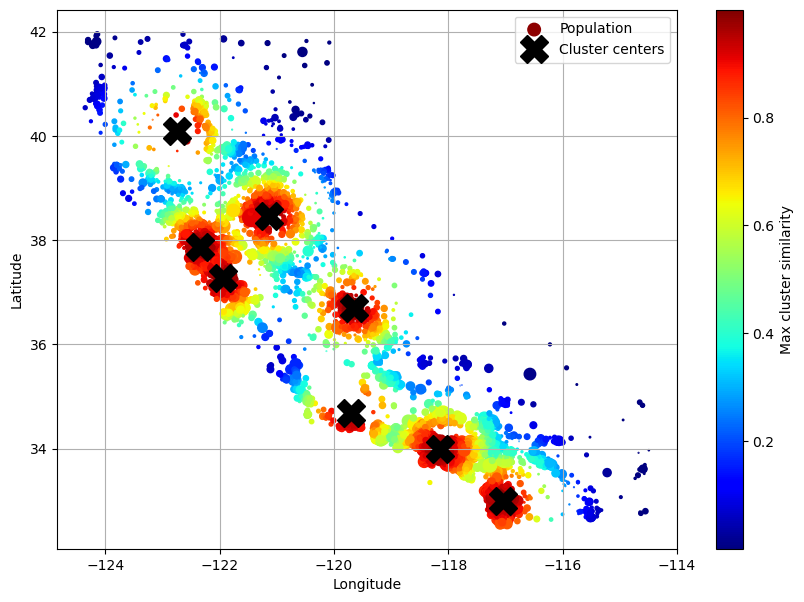

In [46]:
# Took this code from the collab notebook so we can visualize what we just did above.
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_similarity.kmeans_.cluster_centers_[:, 1],
         cluster_similarity.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
plt.show()

##### Transformation Pipelines

We did a lot of operations to ensure that our data is clean and ready for our model. If you look back at the code, the code looks quite fragmented and 
exploratory, and while exploration is good, once we know all the transformations we want to perform, we should have a clean way to apply them sequentially
to our dataset - that's where the pipelines come in.

They allow you to apply all your operations one after the other to our dataset.

In [47]:
from sklearn.pipeline import make_pipeline

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"), # fill empty values with the median
        FunctionTransformer(column_ratio, feature_names_out=ratio_name), # calculate the ratios
        StandardScaler() # scale the values using standardization
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), # fill the empty values with median
    FunctionTransformer(np.log, feature_names_out="one-to-one"), # apply a log function to reduce the heavy tail
    StandardScaler() # scale them using standardization
)

# write a pipeline to handle categorical values
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # fill the empty values with the most frequent
    OneHotEncoder(handle_unknown="ignore"), # one hot encode the categories so that the model does not have to deal with word representations
)
cluster_simil = ClusterSimilarity(random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [48]:
from sklearn.compose import ColumnTransformer, make_column_selector

# Add it all together in a pipeline. https://scikit-learn.org/1.5/modules/generated/sklearn.compose.ColumnTransformer.html
preprocessing = ColumnTransformer([
   ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]), # calculate the ration of the two
   ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
   ("people_per_house", ratio_pipeline(), ["population", "households"]),
   ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
   ("geo", cluster_simil, ["latitude", "longitude"]),
   ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
], remainder=default_num_pipeline) # by default all non-specified columns get dropped. Here we are saying: instead of dropping, apply this estimator to them
                                   # and include them in the output.

In [49]:
housing_prepared = preprocessing.fit_transform(housing)

In [50]:
pd.DataFrame(housing_prepared, columns=preprocessing.get_feature_names_out())

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Clusters 0 similarity,geo__Clusters 1 similarity,...,geo__Clusters 7 similarity,geo__Clusters 8 similarity,geo__Clusters 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age,remainder__income_cat
0,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,8.708837e-08,9.712456e-01,...,3.070969e-17,1.314047e-01,5.740031e-01,0.0,0.0,0.0,1.0,0.0,1.861119,-0.954687
1,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,1.181328e-01,9.738096e-14,...,5.437838e-01,1.735342e-09,2.275194e-10,1.0,0.0,0.0,0.0,0.0,0.907630,1.890078
2,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,2.295286e-08,7.457782e-01,...,1.605970e-17,2.744847e-01,2.839978e-01,0.0,1.0,0.0,0.0,0.0,0.351428,-0.954687
3,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.670700,0.925373,-0.912253,4.618947e-04,3.873884e-20,...,7.405721e-01,2.243339e-14,4.218649e-16,0.0,1.0,0.0,0.0,0.0,-0.919891,-0.954687
4,0.963208,-0.666554,-0.306148,1.437622,1.003590,0.719093,1.481464,0.034537,3.166634e-02,7.905346e-16,...,7.501278e-01,2.890866e-11,3.710912e-12,0.0,0.0,0.0,0.0,1.0,0.589800,-0.006432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,0.804368,-0.452111,-0.269780,0.465581,0.109720,-0.247054,0.379471,0.648953,7.592469e-02,1.255430e-14,...,5.539064e-01,2.304608e-10,4.272885e-11,1.0,0.0,0.0,0.0,0.0,0.987087,0.941823
16508,-0.192328,0.036792,-0.073741,0.454022,0.477277,0.314542,0.402773,-0.637675,1.122830e-01,8.422138e-06,...,1.831519e-04,6.702758e-03,4.498431e-04,0.0,1.0,0.0,0.0,0.0,-0.443146,-0.954687
16509,-0.242492,-0.109987,0.158542,0.824206,0.859552,1.243381,0.889897,0.333540,6.789654e-06,3.595707e-25,...,1.250634e-01,3.348665e-19,2.064542e-20,0.0,0.0,0.0,0.0,1.0,-1.237721,-0.006432
16510,0.259775,-0.360937,-0.210332,0.987851,0.811293,0.579462,1.023329,0.377051,1.096450e-01,6.165959e-14,...,5.435921e-01,1.066970e-09,1.586255e-10,1.0,0.0,0.0,0.0,0.0,0.669257,-0.006432


### 5. Select and Train a Model

At this point of this project, training a model is quite trivial as we have done most of the hard work pre-processing the data.

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x176...
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1763f0e60>)])),
                ('linearregression', LinearRegression())])

We have a pipeline with our LinearRegression model at the end of it so lets make a prediction.

In [53]:
housing_predictions = lin_reg.predict(housing)

In [54]:
housing_predictions[:5]

array([247085.57775978, 397556.65547462, 119417.91338728,  95544.17587666,
       326800.71273616])

In [55]:
housing_labels[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

If you compare our predictions to the actual values you can see that they are off by quite a bit. We need a way to evaluate the performance of the model/calculate
its error. In our case we will be using the RMSE. Sklearn provides us with functions for this as well.

In [56]:
from sklearn.metrics import mean_squared_error

lin_rmse = mean_squared_error(housing_labels, housing_predictions, squared=False)

In [57]:
lin_rmse

68004.52469464045

What the above number tells us is that the our predictions can be off by a margin of error ok 68k which is quite bad.

Let's try with another model.

In [58]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor())
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x176...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1763f0e60>)])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

In [59]:
predictions = tree_reg.predict(housing)

In [60]:
predictions[0:5]

array([458300., 483800., 101700.,  96100., 361800.])

In [61]:
housing_labels[0:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [62]:
tree_rmse = mean_squared_error(housing_labels, predictions, squared=False)
tree_rmse

0.0

Pretty sure this is overfitting! Also, we are testing with our training data. This is why we initially separated out a test set.

We can use the *cross_val_score* function in sklearn to make the validation easier. This function performs cross validation for us by dividing the data set into multiple folds. Then, using one fold as the evaluation set it trains on the other ones and calculates the accurace.

In [63]:
from sklearn.model_selection import cross_val_score

help(cross_val_score)

Help on function cross_val_score in module sklearn.model_selection._validation:

cross_val_score(estimator, X, y=None, *, groups=None, scoring=None, cv=None, n_jobs=None, verbose=0, fit_params=None, pre_dispatch='2*n_jobs', error_score=nan)
    Evaluate a score by cross-validation.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    estimator : estimator object implementing 'fit'
        The object to use to fit the data.

    X : array-like of shape (n_samples, n_features)
        The data to fit. Can be for example a list, or an array.

    y : array-like of shape (n_samples,) or (n_samples, n_outputs),             default=None
        The target variable to try to predict in the case of
        supervised learning.

    groups : array-like of shape (n_samples,), default=None
        Group labels for the samples used while splitting the dataset into
        train/test set. Only used in conjunction with a "Group" :term:`cv`
        instance (

In [64]:
-cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

array([66427.25401572, 63385.2068879 , 66684.11006095, 66261.18361869,
       65448.59933451, 69642.66950942, 67028.43835599, 67959.64229617,
       71128.71526741, 66382.4488777 ])

The goal here to test a few different models to see which fit your scenario and narrow down onto the most suitable one.

### 6. Fine tune your model

## Exercise

### Question 1
Exercise: Try a Support Vector Machine regressor (sklearn.svm.SVR) with various hyperparameters, such as kernel="linear" (with various values for the C hyperparameter) or kernel="rbf" (with various values for the C and gamma hyperparameters). Note that SVMs don't scale well to large datasets, so you should probably train your model on just the first 5,000 instances of the training set and use only 3-fold cross-validation, or else it will take hours. Don't worry about what the hyperparameters mean for now (see the SVM notebook if you're interested). How does the best SVR predictor perform?

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR

In [66]:
svm_pipeline = make_pipeline(preprocessing, SVR())
svm_pipeline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x176...
                                                   'total_rooms', 'population',
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1763f0e60>)])),
                ('svr', SVR())])

In [67]:
# Learn more about the parameters SVR has: https://scikit-learn.org/1.5/modules/generated/sklearn.svm.SVR.html
parameters = {'svr__kernel':('linear', 'rbf'), 'svr__C':[1, .5]}
gs = GridSearchCV(svm_pipeline, parameters, cv=3)

In [68]:
gs.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_ou...
                                                                         ClusterSimilarity(random_state=42),
                                                                         ['latitude',
                                                                          'longitude']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x1763f0e60>)])),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [1, 0.5], 'svr__kernel': ('linear', 'rbf')})

In [69]:
pd.DataFrame(data=gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svr__C,param_svr__kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,2.701066,0.112306,0.675709,0.001119,1,linear,"{'svr__C': 1, 'svr__kernel': 'linear'}",0.092542,0.081481,0.084834,0.086286,0.004631,1
1,3.596197,0.693192,2.085508,0.001022,1,rbf,"{'svr__C': 1, 'svr__kernel': 'rbf'}",-0.041686,-0.056016,-0.050433,-0.049378,0.005897,3
2,2.704647,0.085981,0.683803,0.006060,0.5,linear,"{'svr__C': 0.5, 'svr__kernel': 'linear'}",0.029715,0.017405,0.021835,0.022985,0.005091,2
3,3.136439,0.047629,2.092927,0.010282,0.5,rbf,"{'svr__C': 0.5, 'svr__kernel': 'rbf'}",-0.044903,-0.059376,-0.053566,-0.052615,0.005947,4
